# Stuttering Detection: Advanced Neural Network Analysis
---

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from src.data import DataManager
from src.extractors import WavLMExtractor

## Step 2: Configuration & Operational Flags

In [10]:
# Constants
SAMPLE_LIMIT = None
STRICT_LABELS = True # Set to True to filter out ambiguous samples (Score 1 & 2)
RANDOM_SEED = 42
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
AUDIO_DIR = "Stuttering Events in Podcasts Dataset/clips/stuttering-clips/clips"
FEATURE_DIR = "data/features"
fluent_dir = os.path.join(FEATURE_DIR, "fluent")
disfluent_dir = os.path.join(FEATURE_DIR, "disfluent")

# Operational Flags
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
NUM_CLIPS_TO_EXTRACT = 1000

## Step 3: (Optional) Data Extraction Process

In [11]:
if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    import shutil
    if CLEAN_START and os.path.exists(FEATURE_DIR):
        shutil.rmtree(FEATURE_DIR)
        print("[System] Feature database wiped for clean start.")
    
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    
    extractor.extract_from_dir(
        AUDIO_DIR, 
        output_dir=FEATURE_DIR, 
        label_dict=label_dict, 
        limit=NUM_CLIPS_TO_EXTRACT, 
        random_sample=True
    )
else:
    print("[System] Skipping extraction. Using existing data on disk.")

[System] Skipping extraction. Using existing data on disk.


## Step 4: Standardized Data Loading & Splitting

In [12]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

# Smart Load: 50/50 split
X, y = manager.load_from_folders(fluent_dir, disfluent_dir, limit=SAMPLE_LIMIT, label_dict=label_dict)
X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)

# Preprocessing
X_train_final = manager.preprocess(X_train, method="standard")
X_val_final = manager.preprocess(X_val, method="standard")
X_test_final = manager.preprocess(X_test, method="standard")

print(f"Data Ready: {len(X)} samples.")
print(f"Feature Dim: {X_train_final.shape[1]}")

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).
Data Ready: 14452 samples.
Feature Dim: 768


## Step 5: Optimized MLP Architecture
Uses BatchNorm, Dropout, and ReLU to prevent vanishing gradients and overfitting.

In [13]:
class AdvancedStutterNet(nn.Module):
    def __init__(self, input_size):
        super(AdvancedStutterNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

## Step 6: Training with History Diagnostics

In [14]:
def train_stutternet(model, X_train, y_train, X_val, y_val, epochs=150):
    X_t, y_t = torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1, 1)
    X_v, y_v = torch.FloatTensor(X_val), torch.FloatTensor(y_val).view(-1, 1)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    print("--- Starting Optimization ---")
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            v_out = model(X_v)
            v_loss = criterion(v_out, y_v)
            v_acc = ((torch.sigmoid(v_out) > 0.5).float() == y_v).float().mean()
            
        history['train_loss'].append(loss.item())
        history['val_loss'].append(v_loss.item())
        history['val_acc'].append(v_acc.item())
        
        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch+1:03d} | Loss: {loss.item():.4f} | Val Acc: {v_acc.item():.4f}")
    return history

model = AdvancedStutterNet(X_train_final.shape[1])
history = train_stutternet(model, X_train_final, y_train, X_val_final, y_val)

--- Starting Optimization ---
Epoch 025 | Loss: 0.3305 | Val Acc: 0.8132
Epoch 050 | Loss: 0.1487 | Val Acc: 0.8280
Epoch 075 | Loss: 0.0689 | Val Acc: 0.8349
Epoch 100 | Loss: 0.0485 | Val Acc: 0.8293
Epoch 125 | Loss: 0.0366 | Val Acc: 0.8298
Epoch 150 | Loss: 0.0223 | Val Acc: 0.8358


## Step 7: Performance Diagnostics

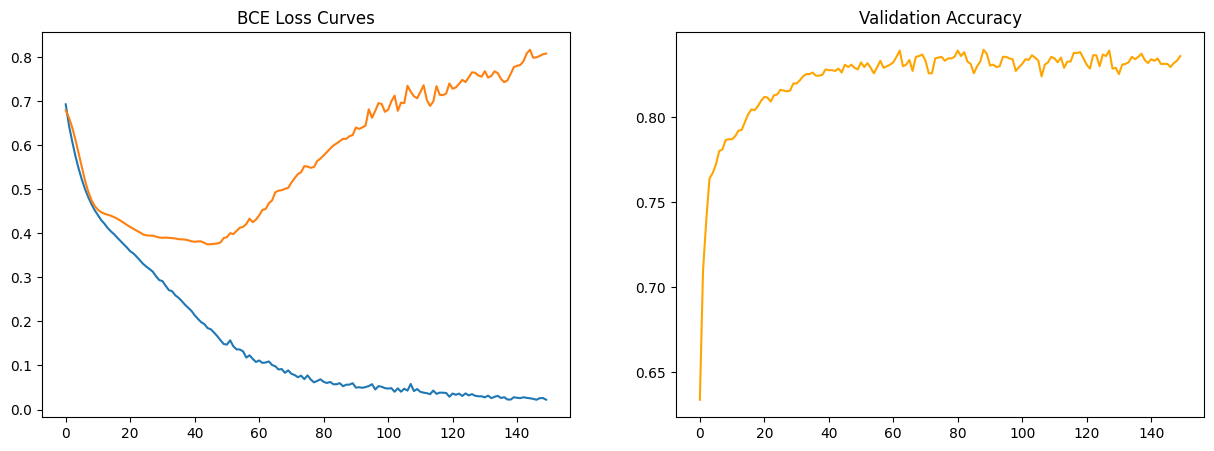

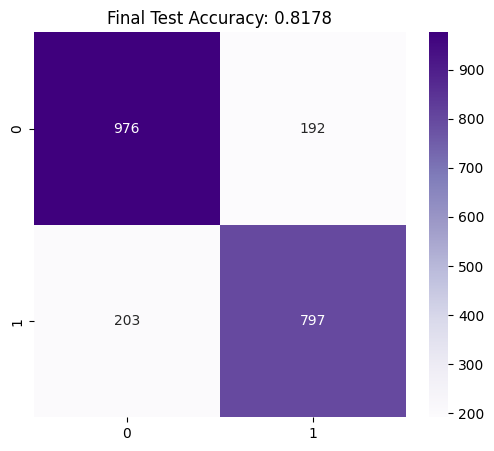

In [15]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_title('BCE Loss Curves')
ax2.plot(history['val_acc'], color='orange')
ax2.set_title('Validation Accuracy')
plt.show()

# Test Set Confusion Matrix
model.eval()
with torch.no_grad():
    y_pred = (torch.sigmoid(model(torch.FloatTensor(X_test_final))) > 0.5).numpy().astype(int).flatten()

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
plt.show()

## Step 8: Model Persistence

In [16]:
torch.save(model.state_dict(), "models/advanced_mlp_stutternet.pth")
print("[System] Advanced Model Exported.")

[System] Advanced Model Exported.
